# Business Problem

A construction company wants to invest in a suburban area.

But before investing, they want answers:

Are people financially strong?
- Is the population capable of buying homes?
- Will the project generate profit?

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Load files 

In [2]:
train_data = pd.read_csv("SalaryData_Train.csv")
test_data = pd.read_csv("SalaryData_Test.csv")

In [3]:
train_data.head()

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Salary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


check the shape of the data where we get how many rows andd colums are there

In [4]:
train_data.shape

(30161, 14)

In [5]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30161 entries, 0 to 30160
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            30161 non-null  int64
 1   workclass      30161 non-null  str  
 2   education      30161 non-null  str  
 3   educationno    30161 non-null  int64
 4   maritalstatus  30161 non-null  str  
 5   occupation     30161 non-null  str  
 6   relationship   30161 non-null  str  
 7   race           30161 non-null  str  
 8   sex            30161 non-null  str  
 9   capitalgain    30161 non-null  int64
 10  capitalloss    30161 non-null  int64
 11  hoursperweek   30161 non-null  int64
 12  native         30161 non-null  str  
 13  Salary         30161 non-null  str  
dtypes: int64(5), str(9)
memory usage: 3.2 MB


Now we get stastical summary of our dataset

In [6]:
train_data.describe()

,age,educationno,capitalgain,capitalloss,hoursperweek
count,30161.000000,30161.000000,30161.000000,30161.000000,30161.000000
mean,38.438115,10.121316,1092.044064,88.302311,40.931269
std,13.134830,2.550037,7406.466611,404.121321,11.980182
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


Check the missing values 

In [7]:
train_data.isnull().sum()

age              0
workclass        0
education        0
educationno      0
maritalstatus    0
occupation       0
relationship     0
race             0
sex              0
capitalgain      0
capitalloss      0
hoursperweek     0
native           0
Salary           0
dtype: int64

## Target Variable Distribution

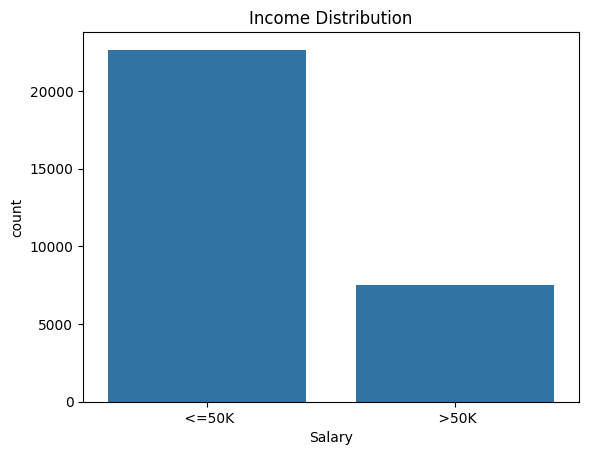

In [8]:
sns.countplot(x=train_data.iloc[:, -1])

plt.title("Income Distribution")
plt.show()

Class imbalance

<=50K : 75%
>50K  : 25%

Meaning:
- More low-income people
- Fewer high-income individuals

## Age Distribution

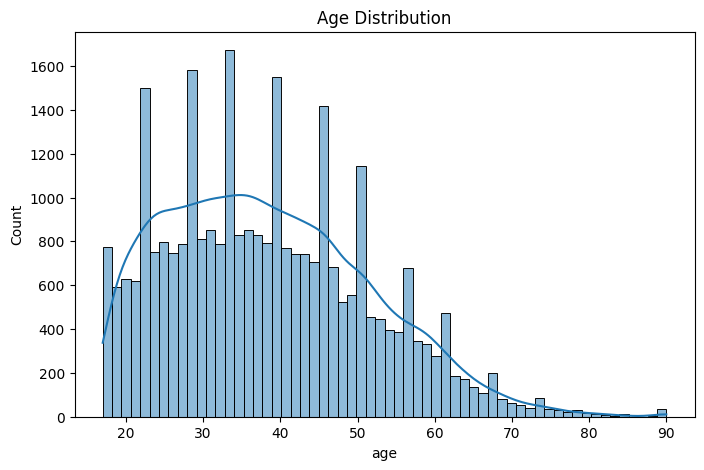

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(train_data['age'], kde=True)

plt.title("Age Distribution")
plt.show()

Most people are middle-age

Business Insight:
- Middle-aged people are financially stable
- Better probability of property investment


## Education Analysis

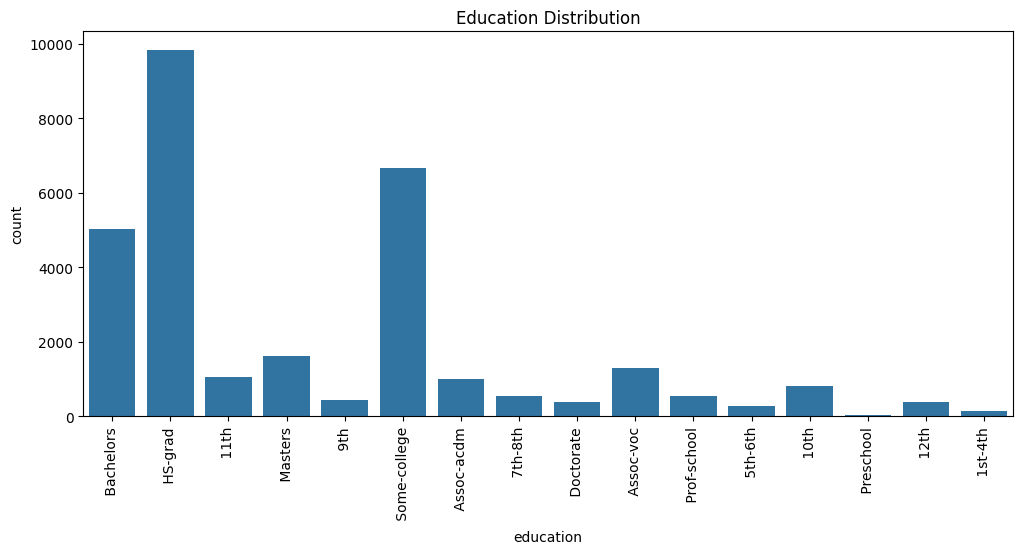

In [10]:
plt.figure(figsize=(12,5))

sns.countplot(x='education', data=train_data)

plt.xticks(rotation=90)

plt.title("Education Distribution")
plt.show()

- Higher education = higher income probability
- Better real-estate market

## Occupation Analysis

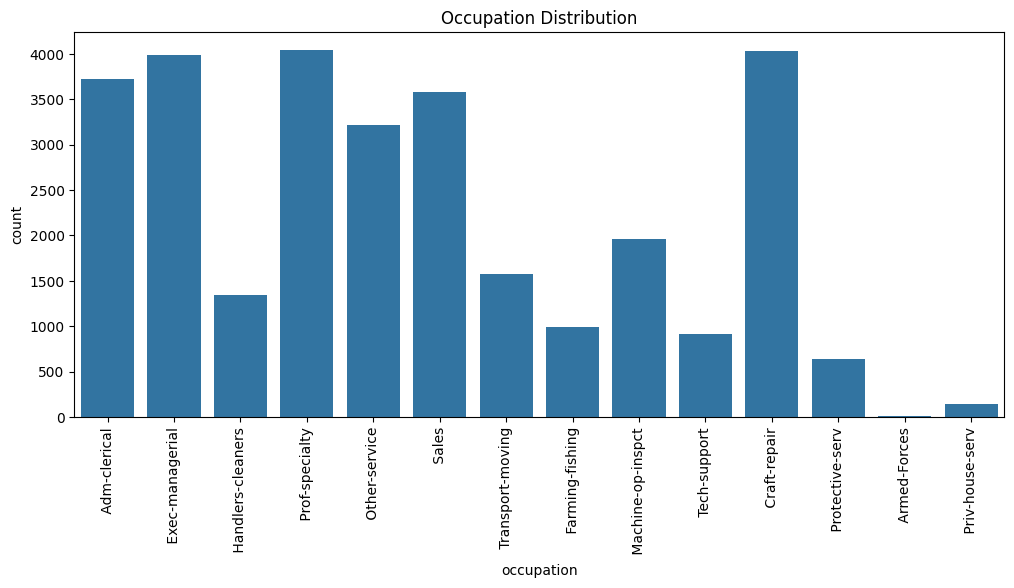

In [11]:
plt.figure(figsize=(12,5))

sns.countplot(x='occupation', data=train_data)

plt.xticks(rotation=90)

plt.title("Occupation Distribution")
plt.show()

Executive/managerial, prof-speciliity,ccraft rrepair jobs indicate stronger economy

## Relationship Between Age and Income

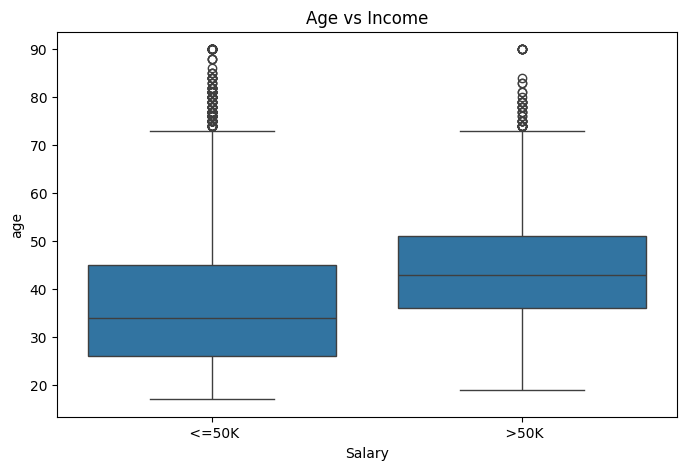

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=train_data.iloc[:, -1],
    y=train_data['age']
)

plt.title("Age vs Income")
plt.show()

Higher-income individuals tend to be older

Business Meaning:

Financial maturity increases salaryHigher-income individuals tend to be older


### Age vs Hours pe rweek

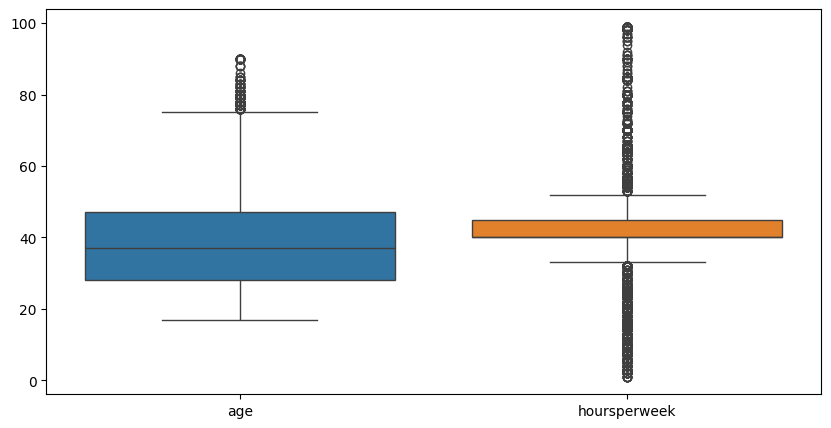

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train_data[['age','hoursperweek']])
plt.show()

Some numerical features contain outliers. 
However, SVM with scaling can handle moderate outliers effectively.

Features like education, occupation, and capital gain strongly influence salary prediction because they represent socioeconomic status and earning potential.

## Hours-per-week Analysis

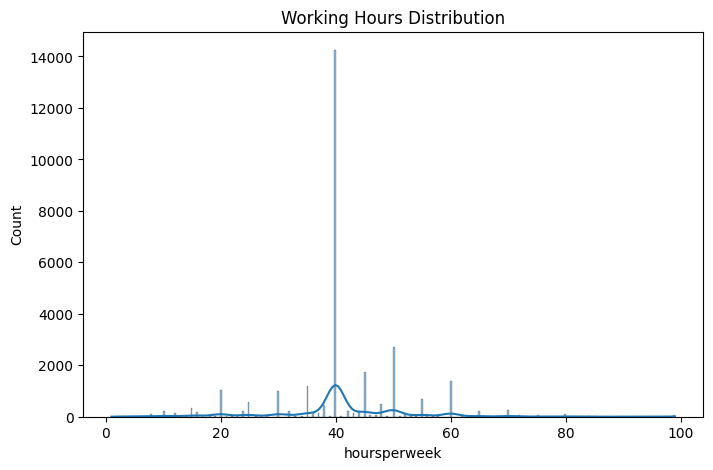

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(train_data['hoursperweek'], kde=True)

plt.title("Working Hours Distribution")
plt.show()

People working more hours may:

- Earn more income
- Have stronger purchasing powerPeople working more hours may:


SVM understands only numbers so We must encode categorical data.

In [15]:
categorical_cols = train_data.select_dtypes(include=['object']).columns
categorical_cols

C:\Users\rajpu\AppData\Local\Temp\ipykernel_6244\457474526.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_data.select_dtypes(include=['object']).columns


Index(['workclass', 'education', 'maritalstatus', 'occupation', 'relationship',
       'race', 'sex', 'native', 'Salary'],
      dtype='str')

In [16]:
for col in categorical_cols:
    
    le = LabelEncoder()
    
    train_data[col] = le.fit_transform(train_data[col])
    
    test_data[col] = le.transform(test_data[col])

Converted:

- columnA → 1
- columnB → 0

Without encoding:
- SVM cannot calculate distances

## Correlation Heatmap

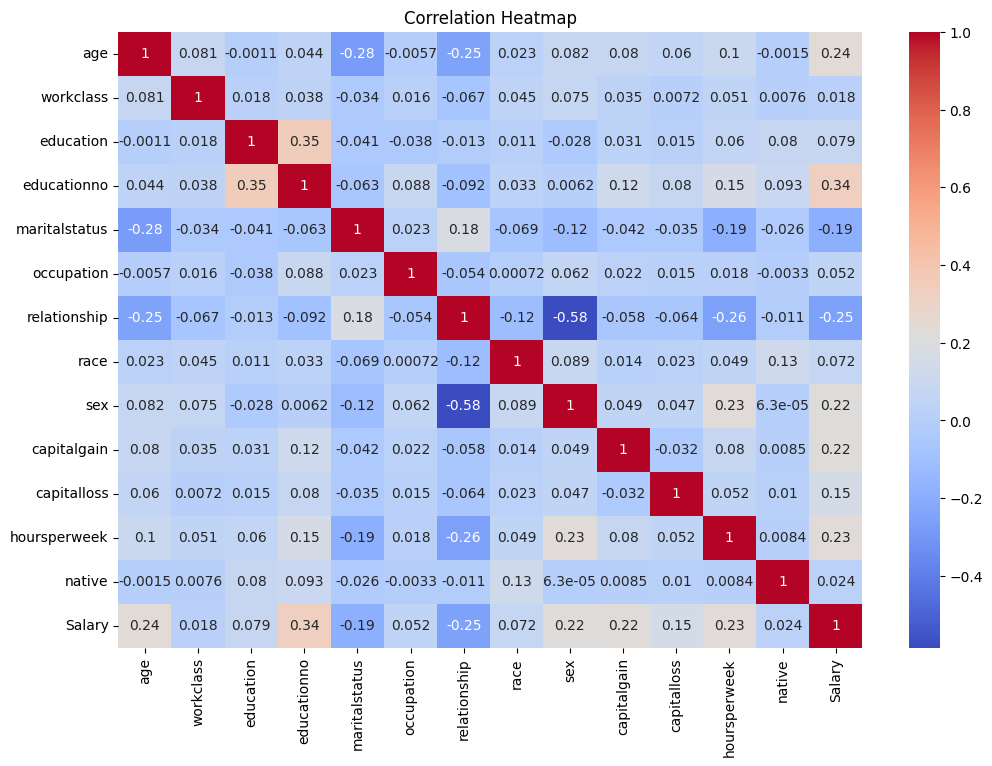

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

High-skilled populations increase investment potential

## Train Test Split

In [18]:
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

Apply Scaling because SVM uses geometric distance calculations to create hyperplanes. Features with larger magnitudes dominate the boundary if scaling is not applied.
After scaling we get
-  Mean ≈ 0
- Standard deviation ≈ 1

which prevents feature domination



In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Build SVM Model using Linear Kernel. It works when Data is linearly separable
we hhave  diffrentt  different types  of kernl  here ex RBF Kernel  Polynomial Kernel

RBF:

- Handles non-linear patterns
- Usually best-performing kernel

on the other hand 
Polynomial kernel:

- Creates curved boundaries
- Can overfit sometimes

In [20]:
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Prediction

In [21]:
y_pred_linear = svm_linear.predict(X_test_scaled)

## Accuracy

In [22]:
train_acc = svm_linear.score(X_train_scaled, y_train)
test_acc = svm_linear.score(X_test_scaled, y_test)

print(train_acc)
print(test_acc)

0.8106826696727563
0.8088977423638778


80% predictions are correct

In [26]:
cm = confusion_matrix(y_test, y_pred_linear)

Text(0.5, 1.0, 'Confusion Matrix')

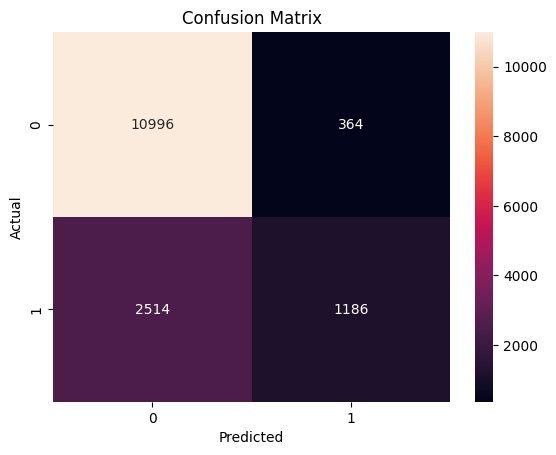

In [27]:
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [29]:
print(classification_report(y_test, y_pred_linear))

              precision    recall  f1-score   support

           0       0.81      0.97      0.88     11360
           1       0.77      0.32      0.45      3700

    accuracy                           0.81     15060
   macro avg       0.79      0.64      0.67     15060
weighted avg       0.80      0.81      0.78     15060



In [30]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred_rbf))

0.845883134130146


In [31]:
svm_poly = SVC(kernel='poly')

svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred_poly))

0.8409030544488711


It Turned out RBF Kernel is the Best model because it Captures complex income patterns better

### Hyperparameter Tuning
-  Parameter ---  Meaning      
-  C    ---     Penalty        
-  gamma  ---   Curve complexity 
-  kernel ---    Boundary type    


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10],
    'gamma':[1,0.1,0.01],
    'kernel':['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=2
)

grid.fit(X_train_scaled, y_train)
 
print(grid.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.7min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.7min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.5min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.3min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.5min
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  27.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  27.6s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  28.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  26.8s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  26.8s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  29.0s
[CV] END ......................C=0.1, gamma=0.01,



Highly educated people earn higher salaries

Meaning:Premium housing demand possible

Middle-aged professionals have stable income

which Means Better property buyers

High-income population exists significantly that Means good real-estate opportunity

Investment in the suburban area is viable.

Because:

- Strong earning population exists
- Educated professionals dominate
- Income patterns support housing demand

## Support vectors are the critical data points closest to the decision boundary. SVM creates an optimal hyperplane by maximizing the margin between classes.